In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

PATH='/content/drive/MyDrive/Fraud Detection'
os.chdir(PATH)

os.getcwd()

'/content/drive/MyDrive/Fraud Detection'

In [3]:
os.listdir()

['training.ipynb',
 'sample_submission.csv',
 'test_identity.csv',
 'train_identity.csv',
 'test_transaction.csv',
 'train_transaction.csv',
 'pipeline.pkl']

In [4]:
import pickle

import numpy as np
import pandas as pd
import shap
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [5]:
df=pd.read_csv("train_transaction.csv")

In [6]:
df.shape

(590540, 394)

In [7]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Checking memory Util

In [8]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(2062.0711002349854)

In [9]:
def reduce_mem_usage(df):
    import numpy as np

    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Initial memory usage: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min >= 0:
                    if c_max < 255:
                        df[col] = df[col].astype(np.uint8)
                    elif c_max < 65535:
                        df[col] = df[col].astype(np.uint16)
                    else:
                        df[col] = df[col].astype(np.uint32)
                else:
                    df[col] = df[col].astype(np.int32)

            else:
                df[col] = df[col].astype(np.float32)

        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Reduced memory usage: {end_mem:.2f} MB")
    print(f"Reduction: {100 * (start_mem - end_mem) / start_mem:.1f}%")

    return df

In [10]:
df = reduce_mem_usage(df)

Initial memory usage: 1775.15 MB
Reduced memory usage: 861.11 MB
Reduction: 51.5%


In [11]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(861.1204214096069)

Missing Values Cleanup

In [12]:
missing=df.isnull().sum()

In [13]:
missing=missing[missing>0].sort_values(ascending=False)
missing.head(20)

,0
dist2,552913
D7,551623
D13,528588
D14,528353
D12,525823
D6,517353
D8,515614
D9,515614
V154,508595
V153,508595


In [14]:
missing_ratio=(df.isnull().sum()/len(df))*100

In [15]:
missing_ratio=missing_ratio[missing_ratio>0].sort_values(ascending=False)
missing_ratio.head(20)

,0
dist2,93.628374
D7,93.409930
D13,89.509263
D14,89.469469
D12,89.041047
D6,87.606767
D8,87.312290
D9,87.312290
V154,86.123717
V153,86.123717


In [16]:
threshold = 80

cols_to_drop = missing_ratio[missing_ratio > threshold].index
cols_to_drop

Index(['dist2', 'D7', 'D13', 'D14', 'D12', 'D6', 'D8', 'D9', 'V154', 'V153',
       'V162', 'V161', 'V163', 'V155', 'V156', 'V138', 'V142', 'V149', 'V148',
       'V147', 'V146', 'V139', 'V140', 'V157', 'V158', 'V141', 'V159', 'V166',
       'V150', 'V145', 'V144', 'V165', 'V164', 'V152', 'V160', 'V151', 'V143',
       'V339', 'V334', 'V336', 'V335', 'V333', 'V332', 'V331', 'V330', 'V326',
       'V327', 'V328', 'V329', 'V322', 'V323', 'V324', 'V325', 'V338', 'V337'],
      dtype='object')

In [17]:
df = df.drop(columns=cols_to_drop)

df.shape

(590540, 339)

In [18]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [19]:
print(len(num_cols))
print(len(cat_cols))

325
14


In [20]:
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

In [21]:
for col in cat_cols:
    if 'missing' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories('missing')
    df[col] = df[col].fillna('missing')

In [22]:
df.isnull().sum().sum()

np.int64(0)

Categorical Variables

In [23]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'],
      dtype='object')

In [24]:
encoders={}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 339 entries, TransactionID to V321
dtypes: float32(321), int64(14), uint16(1), uint32(2), uint8(1)
memory usage: 792.4 MB


Training

In [26]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

print(X.shape, y.shape)

(590540, 338) (590540,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print(X_train.shape, X_test.shape)

(472432, 338) (118108, 338)


Instead of SMOTE

In [29]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
scale_pos_weight = (len(y_train_sm) - sum(y_train_sm)) / sum(y_train_sm)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: isFraud
0    455902
1     16530
Name: count, dtype: int64
After SMOTE: isFraud
0    455902
1    455902
Name: count, dtype: int64


### XGBoost

In [30]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    tree_method='hist'
)

In [31]:
model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

Testing

In [32]:
y_pred = model.predict_proba(X_test)[:, 1]

In [33]:
auc = roc_auc_score(y_test, y_pred)
auc

np.float64(0.9183509357937205)

In [34]:
y_pred_label = model.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred_label))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.86      0.44      0.58      4133

    accuracy                           0.98    118108
   macro avg       0.92      0.72      0.79    118108
weighted avg       0.98      0.98      0.97    118108



In [36]:
cm = confusion_matrix(y_test, y_pred_label)
print(cm)

[[113672    303]
 [  2306   1827]]


In [37]:
pr_auc = average_precision_score(y_test, y_pred)
print("PR-AUC:", pr_auc)

PR-AUC: 0.6316805831825963


In [38]:
f1 = f1_score(y_test, y_pred_label)
print("F1 Score:", f1)

F1 Score: 0.5834264729362925


### Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_jobs=-1,
                       random_state=42)

Testing

In [53]:
y_pred_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_label_rf = rf_model.predict(X_test)

In [54]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print("PR-AUC:", average_precision_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_label_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_label_rf))

ROC-AUC: 0.8984987666345386
PR-AUC: 0.555809582857745

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94    113975
           1       0.21      0.74      0.33      4133

    accuracy                           0.89    118108
   macro avg       0.60      0.82      0.64    118108
weighted avg       0.96      0.89      0.92    118108


Confusion Matrix:
[[102622  11353]
 [  1074   3059]]


### Comparing Results

In [55]:
print("XGBoost ROC-AUC:", auc)
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

XGBoost ROC-AUC: 0.9183509357937205
Random Forest ROC-AUC: 0.8984987666345386


SHAP

In [39]:
explainer = shap.Explainer(model, X_train)

In [40]:
sample = X_test.sample(100, random_state=42)
shap_values = explainer(sample)

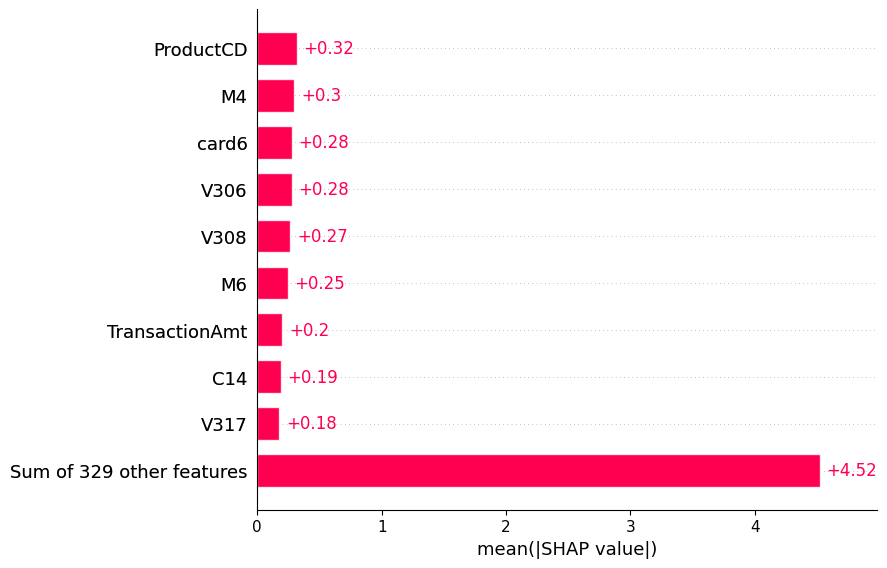

In [41]:
shap.plots.bar(shap_values)

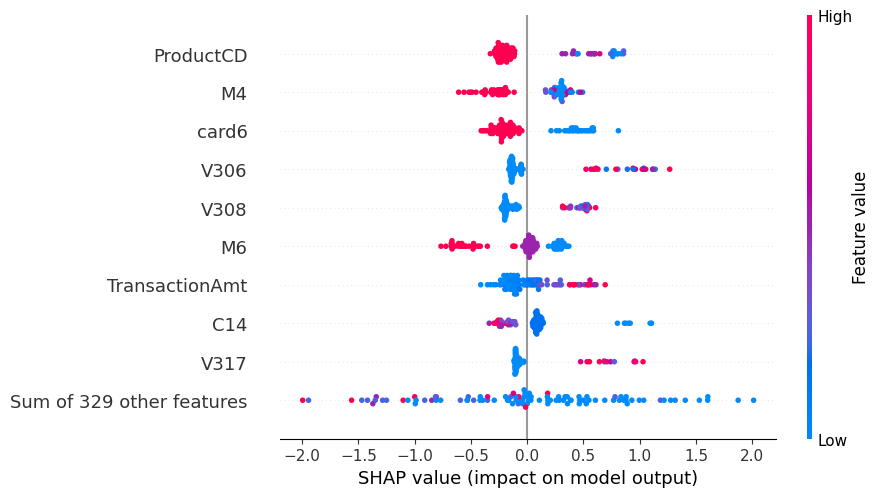

In [42]:
shap.plots.beeswarm(shap_values)

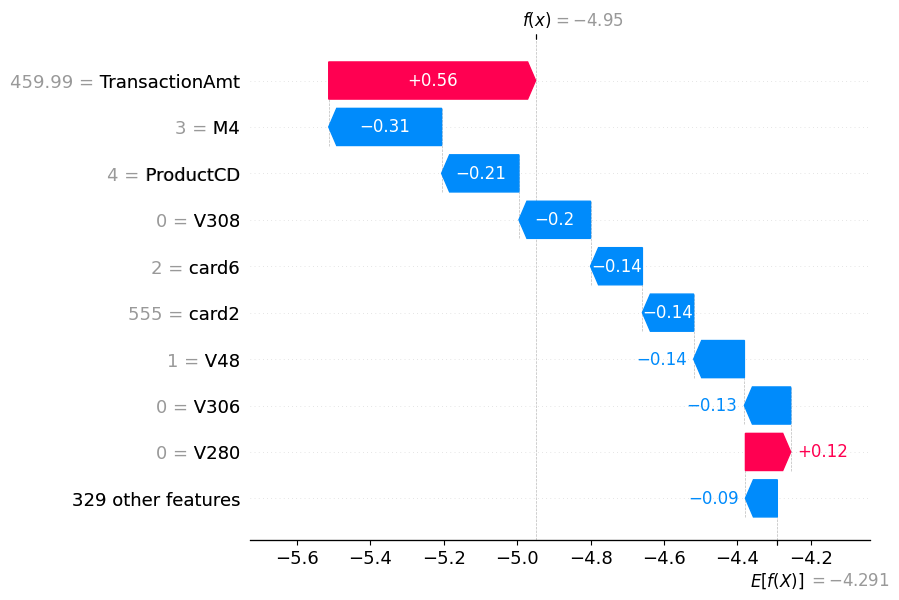

In [43]:
shap.plots.waterfall(shap_values[0])

Preprocessing+Feature Engineering Classes

In [50]:
class DataPreprocessor:
    def __init__(self, cols_to_drop, num_cols, cat_cols):
        self.cols_to_drop = cols_to_drop
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.medians = {}

    def fit(self, df):
        for col in self.num_cols:
            self.medians[col] = df[col].median()
        return self

    def transform(self, df):
        df = df.copy()

        df = df.drop(columns=self.cols_to_drop, errors='ignore')

        for col in self.num_cols:
            if col in df.columns:
                df[col] = df[col].fillna(self.medians[col])

        for col in self.cat_cols:
            if col in df.columns:
                df[col] = df[col].fillna('missing')

        return df

In [45]:
class FeatureEngineer:
    def __init__(self):
        self.encoders = {}

    def fit(self, df, cat_cols):
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = df[col].astype(str)
            le.fit(df[col])
            self.encoders[col] = le
        return self

    def transform(self, df):
        df = df.copy()

        for col, le in self.encoders.items():
            if col in df.columns:
                df[col] = df[col].astype(str)
                df[col] = df[col].map(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )

        return df

In [46]:
preprocessor = DataPreprocessor(cols_to_drop, num_cols, cat_cols)
preprocessor.fit(df)

feature_engineer = FeatureEngineer()
feature_engineer.fit(df, cat_cols)

In [47]:
pipeline = {
    "model": model,
    "preprocessor": preprocessor,
    "feature_engineer": feature_engineer,
    "features": list(X.columns)
}

In [48]:
with open("pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)